In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn._vf import MLPUnconditionalVF
import matplotlib.pyplot as plt
# from sc_flow.backends.torch.methods import BaseMethod

In [3]:
from abc import ABC, abstractmethod
from collections.abc import Callable
from typing import Any

import torch
from torch import nn

import sc_flow.methods as basemethods
from sc_flow.backends.torch._types import TensorLike
from sc_flow.backends.torch.nn._vf import BaseVelocityField
from sc_flow.backends.torch.probability_paths import BaseProbabilityPath

__all__ = ["BaseMethod"]


class Solver(ABC, nn.Module):
    """Abstract Base Class for Solvers"""

    @abstractmethod
    def solve(self, vf, source: torch.Tensor | None = None, **kwargs: Any) -> torch.Tensor:
        """Solve method to be implemented by subclasses."""
        pass


LinTerm = tuple[torch.Tensor, torch.Tensor]
QuadTerm = tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, torch.Tensor | None]
GENOTDataMatchFn = Callable[[LinTerm], torch.Tensor] | Callable[[QuadTerm], torch.Tensor]


class BaseMethod(basemethods.FlowMatching):
    """TODO."""

    def __init__(
        self,
        vf: BaseVelocityField,
        probability_path: BaseProbabilityPath,
        time_sampler: Callable[[int], torch.Tensor],  # [[int], np.ndarray],
        solver: Solver | Any,
        match_fn: Any,  # TODO: adapt type
        ema: int = 1,
        generate_from_noise: bool = False,
        opt: Any = None,
        control_key: str | None = None,
        noise_distribution: Callable[[tuple[int, ...]], torch.Tensor] | None = None,
        **kwargs: Any,  # TODO Add parcing of kwargs
    ):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.ema = ema
        self.generate_from_noise = generate_from_noise
        self.control_key = control_key
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self.solver = solver
        self.noise_distribution = noise_distribution or (lambda shape: torch.randn(size=shape))
        # TODO: add cfg

        self._is_trained = False
        self.vf_step_fn = self._get_vf_step_fn()

    @staticmethod
    def _prepare_data(
        batch: dict[str, Any],  # TODO adapt type
    ) -> tuple[
        tuple[torch.Tensor, torch.Tensor],
        tuple[torch.Tensor | None, ...],
    ]:
        """TODO"""
        src_lin, src_quad = batch.get("src_cell_data"), batch.get("src_cell_data_quad")
        tgt_lin, tgt_quad = batch.get("tgt_cell_data"), batch.get("tgt_cell_data_quad")

        if src_quad is None and tgt_quad is None:  # lin
            source, target = src_lin, tgt_lin
            arrs = src_lin, tgt_lin
        elif src_lin is None and tgt_lin is None:  # quad
            source, target = src_quad, tgt_quad
            arrs = src_quad, tgt_quad
        elif all(arr is not None for arr in (src_lin, tgt_lin, src_quad, tgt_quad)):  # fused quad
            source = torch.concat([src_lin, src_quad], dim=1)
            target = torch.concat([tgt_lin, tgt_quad], dim=1)
            arrs = src_quad, tgt_quad, src_lin, tgt_lin
        else:
            raise RuntimeError("Cannot infer OT problem type from data.")

        return (source, target), arrs  # type: ignore[return-value]

    def step_fn(
        self,
        batch: dict[str, Any],  # TODO Adapt types
    ) -> torch.Tensor:
        """Single step function of the solver.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, torch.Tensor]
        """
        condition = batch.get("condition")
        (source, target), matching_data = self._prepare_data(batch)
        n = source.shape[0]
        time = self.time_sampler(n)

        src_ixs, tgt_ixs = self.match_fn(*matching_data)

        source, target = source[src_ixs], target[tgt_ixs]
        loss = self.vf_step_fn(
            time,
            source,
            target,
            condition,
        )
        return loss

    def _get_vf_step_fn(self):
        def vf_step_fn(
            time: torch.Tensor,
            source: torch.Tensor,
            target: torch.Tensor,
            conditions: dict[str, torch.Tensor] | Any,
        ):
            def loss_fn(
                t: torch.Tensor,
                source: torch.Tensor,
                target: torch.Tensor,
                conditions: dict[str, torch.Tensor],
            ) -> torch.Tensor:
                if self.generate_from_noise:
                    latent = self.noise_distribution(target.shape)
                    x_t = self.probability_path.compute_xt(t, latent, target)
                    if self.control_key is not None:
                        conditions = conditions.copy()
                        conditions[self.control_key] = source
                else:
                    x_t = self.probability_path.compute_xt(t, source, target)
                v_t = self.vf(
                    t,
                    x_t,
                    conditions,
                    source,
                )
                u_t = self.probability_path.compute_ut(t, x_t, source, target)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            with torch.autocast("cuda"):
                loss = loss_fn(time, source, target, conditions)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def train_step(
        self,
        batch: dict[str, TensorLike],
        prng_key,
    ) -> float:
        """Training step of the method.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, TensorLike]

        :param rng_step_fn: Random number generator for the step function. Default is None.
        :type rng_step_fn: TensorLike | None, optional
        """
        loss = self.step_fn(batch)
        return float(loss.cpu())

    def get_condition_embedding(self, condition: dict[str, torch.Tensor], return_as_numpy=True) -> torch.Tensor:
        """"""  # noqa
        pass

    def predict(
        self,
        x: torch.Tensor | dict[str, torch.Tensor],
        condition: dict[str, torch.Tensor] | None = None,
        rng: torch.Tensor | None = None,
        rng_genot: torch.Tensor | None = None,
        batched: bool = False,
        **kwargs: Any,
    ) -> torch.Tensor | tuple[torch.Tensor, TensorLike] | dict[str, torch.Tensor]:
        """Generate the push-forward of ``x`` under condition ``condition``.

        This function solves the ODE learnt with
        the :class:`~cellflow.networks.ConditionalVelocityField`.

        Parameters
        ----------
        x
            Input data of shape [batch_size, ...].
        condition
            Condition of the input data of shape [batch_size, ...].
        rng
            Random number generator to sample from the latent distribution,
            only used if ``condition_mode='stochastic'``. If :obj:`None`, the
            mean embedding is used.
        rng_genot
            Random generate used to sample from the latent distribution in cell space.
        batched
            Whether to use batched prediction. This is only supported if the input has
            the same number of cells for each condition. For example, this works when using
            :class:`~cellflow.data.ValidationSampler` to sample the validation data.
        kwargs
            Keyword arguments for :func:`diffrax.diffeqsolve`.

        Returns
        -------
        The push-forward distribution of ``x`` under condition ``condition``.
        """
        if batched and not x:
            return {}

        if batched:
            if isinstance(x, dict):
                keys = sorted(x.keys())
            if condition is not None:
                condition_keys = sorted(set().union(*(condition[k].keys() for k in keys)))

            # assert that the number of cells is the same for each condition
            n_cells = x[keys[0]].shape[0]
            for k in keys:
                assert x[k].shape[0] == n_cells, "The number of cells must be the same for each condition"
            src_inputs = torch.stack([x[k] for k in keys], axis=0)
            batched_conditions = {}
            for cond_key in condition_keys:
                batched_conditions[cond_key] = torch.stack([condition[k][cond_key] for k in keys])
            pred_targets = self._predict_step(x=src_inputs, condition=batched_conditions)
            return {k: pred_targets[i] for i, k in enumerate(keys)}
        else:
            if isinstance(x, dict):
                raise TypeError(f"State `x` should be of type `torch.Tensor` and not `{type(x)}`")
            x_pred = self._predict_step(x, condition)
            return x_pred

    def _predict_step(self, x, condition, time=None, **kwargs) -> torch.Tensor:
        if not time:
            time = torch.linspace(0.0, 1.0, 101)

        x_pred = self.solver.solve(
            self.vf,
            source=x,
            time=time,
            vf_kwargs={"condition_dict": condition},
            rtol=1e-6,
            atol=1e-7,
            return_trajectory=False,
        )
        print(x_pred.shape)
        return x_pred

In [4]:
import logging
from collections.abc import Callable
from functools import partial
from typing import Literal

import numpy as np
import ot as pot
import torch


def ot_linear_coupling(
    source: torch.Tensor,
    target: torch.Tensor,
    cost_fn: Callable | None = None,
    scale_cost: float | Literal["mean", "max_cost", "median"] = "mean",
    method: Literal["exact", "sinkhorn", "partial", "unbalanced", None] = None,
    of_fn: Callable | None = None,
    reg: float = 5e-1,
    reg_m: float = 1.0,
    **kwargs,
) -> tuple[np.ndarray, np.ndarray] | tuple[np.ndarray, np.ndarray, torch.Tensor]:
    """Matches the :param:`source` and :param:`target` groups and returns the respective indices.

    :param source: A tensor of values containing the data coming from the source distribution.
    :type source: class:`torch.Tensor`

    :param target: A tensor of values containing the data coming from the target distribution.
    :type target: class:`torch.Tensor`

    #TODO
    """
    if method is None:
        method = "sinkhorn"

    if cost_fn is None:
        cost_fn = lambda source, target: torch.cdist(source, target) ** 2

    # computing weights
    src_weights = pot.unif(source.shape[0])
    tgt_weights = pot.unif(target.shape[0])
    # moving arrays to torch tensors
    if isinstance(source, np.ndarray):
        source = torch.from_numpy(source)
    if isinstance(target, np.ndarray):
        target = torch.from_numpy(target)
    # flattening tensors
    source = torch.flatten(source, start_dim=1)
    target = torch.flatten(target, start_dim=1)
    # computing cost matrix
    distance_matrix = cost_fn(source, target)
    # normalization of cost
    if scale_cost == "mean":
        distance_matrix = distance_matrix / distance_matrix.mean()
    elif scale_cost == "max":
        distance_matrix = distance_matrix / distance_matrix.max()
    elif scale_cost == "median":
        distance_matrix = distance_matrix / distance_matrix.median()
    elif isinstance(scale_cost, float):
        distance_matrix = distance_matrix / scale_cost

    if method == "exact":
        ot_fn = pot.emd
    elif method == "sinkhorn":
        if reg is None:
            msg = f"{method=} requires `reg` to be a `float`, `None` found"
            raise ValueError(msg)
        ot_fn = partial(pot.sinkhorn, reg=reg, **kwargs)
    elif method == "partial":
        if reg is None:
            msg = f"{method=} requires `reg` to be a `float`, `None` found"
            raise ValueError(msg)
        ot_fn = partial(pot.partial.entropic_partial_wasserstein, reg=reg, **kwargs)
    elif method == "unbalanced":
        if reg is None:
            msg = f"{method=} requires `reg` to be a `float`, `None` found"
            raise ValueError(msg)
        if reg_m is None:
            msg = f"{method=} requires `reg_m` to be a `float`, `None` found"
            raise ValueError(msg)
        ot_fn = partial(pot.unbalanced.sinkhorn_knopp_unbalanced, reg=reg, reg_m=reg_m, **kwargs)
    elif method not in ["exact", "sinkhorn", "partial", "unbalanced"]:
        msg = f"{method=} is not found, please specify a custom `method` in `ot_fn`"
        raise ValueError(msg)

    # computing coupling matrix
    coupling_matrix = ot_fn(src_weights, tgt_weights, distance_matrix.detach().cpu().numpy())
    # checking for numerical errors in the coupling matrix
    if not np.all(np.isfinite(coupling_matrix)):
        msg = f"Non finite values found in `coupling_matrix` \n {coupling_matrix=} \n {source=} \n {target=} \n {distance_matrix.mean()=} \n {distance_matrix.max()=}"
        # logger.warning(msg)
    if np.abs(coupling_matrix.sum()) < 1e-8:
        msg = ""
        # logger.warning(msg)
        coupling_matrix = np.ones_like(coupling_matrix) / coupling_matrix.size
    # retrieving coupling probabilities
    coupling_probs = coupling_matrix.flatten()
    coupling_probs = coupling_probs / coupling_probs.sum()
    # sampling indices
    choices = np.random.choice(
        coupling_matrix.shape[0] * coupling_matrix.shape[1],
        p=coupling_probs,
        size=source.shape[0],
        replace=False,
    )
    source_idxs, target_idxs = np.divmod(choices, coupling_matrix.shape[1])
    if "return_matrix" in kwargs and kwargs["return_matrix"]:
        return source_idxs, target_idxs, coupling_matrix
    return source_idxs, target_idxs

In [5]:
from typing import Any, Literal

from torch import Tensor, device
from torchdiffeq import odeint

from sc_flow.backends.torch.nn._vf import BaseVelocityField

from abc import ABC, abstractmethod
from typing import Any

from torch import nn


class Solver(ABC, nn.Module):
    """Abstract Base Class for Solvers"""

    @abstractmethod
    def solve(self, *, source: Tensor | None = None, **kwargs: Any) -> Tensor:
        """Solve method to be implemented by subclasses."""
        ...


class ODESolver(Solver):
    r"""Class for solving deterministic ordinary differential equations (ODEs) with :func:`torchdiffeq.odeint`.

    :param method: (Optional) Integration scheme used by ``torchdiffeq``. Defaults to ``"euler"``. Other valid options depend on ``torchdiffeq``.
    :type method: class:`str`

    :param device_id: (Optional) Identifier for the target compute device. Choices are ``"cpu"`` or ``"cuda"``. Defaults to ``"cpu"``.
    :type device_id: class:`Literal["cuda", "cpu"]`
    """

    def __init__(
        self,
        method: str = "euler",
        device_id: Literal["cuda", "cpu"] = "cpu",
    ) -> None:
        super().__init__()
        self.method = method
        self.device = device(device_id)

    def solve(
        self,
        vf: BaseVelocityField,
        source: Tensor,
        time: Tensor,
        *,
        rtol: float,
        atol: float,
        vf_kwargs: dict[str, Any] | None = None,
        solver_kwargs: dict[str, Any] | None = None,
        return_trajectory: bool = True,
    ) -> Tensor:
        r"""Integrates the ODE defined by the provided velocity field.

        :param vf: Velocity field providing the time-dependent dynamics. Must implement :meth:`BaseVelocityField.get_vf_fn`.
        :type vf: class:`BaseVelocityField`

        :param source: Initial state of the ODE.
        :type source: class:`torch.Tensor`

        :param time: Time grid over which to integrate the ODE.
        :type time: class:`torch.Tensor`

        :param rtol: Relative tolerance for the ODE solver.
        :type rtol: class:`float`

        :param atol: Absolute tolerance for the ODE solver.
        :type atol: class:`float`

        :param vf_kwargs: (Optional) Keyword arguments passed to
            :meth:`BaseVelocityField.get_vf_fn`.
        :type vf_kwargs: class:`dict[str, Any] | None`

        :param solver_kwargs: (Optional) Keyword arguments forwarded directly to
            :func:`torchdiffeq.odeint`.
        :type solver_kwargs: class:`dict[str, Any] | None`

        :param return_trajectory: When ``True``, returns the full trajectory, else returns only the final state at the last time point.
        :type return_trajectory: class:`bool`

        :returns: Either the full state trajectory or the final state depending on
            :param:`return_trajectory`.
        :rtype: class:`torch.Tensor`
        """
        if solver_kwargs is None:
            solver_kwargs = {}

        if vf_kwargs is None:
            vf_kwargs = {}

        diff_eqn = vf.get_vf_fn(**vf_kwargs)

        source = source.to(self.device)
        time = time.to(self.device)

        trajectory = odeint(
            diff_eqn,
            source,
            time,
            rtol=rtol,
            atol=atol,
            method=self.method,
            **solver_kwargs,
        )

        if return_trajectory:
            return trajectory
        else:
            return trajectory[-1]

In [6]:
def dummy_time_sampler(n):
    return torch.rand(size=(n,))

In [7]:
from collections.abc import Callable
from typing import Literal

import numpy as np
import torch

logger = logging.getLogger(__name__)


def independent_coupling(
    source: torch.Tensor,
    target: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray]:
    """Matches the :param:`source` and :param:`target` groups and returns the respective indices.

    :param source: A tensor of values containing the data coming from the source distribution.
    :type source: class:`torch.Tensor`

    :param target: A tensor of values containing the data coming from the target distribution.
    :type target: class:`torch.Tensor`

    Returns
    -------
    ## TODO
    """
    # randomy permuting the tensors
    src_random_perm_idx = np.random.choice(np.arange(source.shape[0]), size=source.shape[0], replace=False)
    tgt_random_perm_idx = np.random.choice(np.arange(target.shape[0]), size=source.shape[0], replace=False)

    min_shape = min(src_random_perm_idx.shape[0], tgt_random_perm_idx.shape[0])

    return src_random_perm_idx[:min_shape], tgt_random_perm_idx[:min_shape]

In [8]:
help(MLPUnconditionalVF)

Help on class MLPUnconditionalVF in module sc_flow.backends.torch.nn._vf:

class MLPUnconditionalVF(BaseVelocityField)
 |  MLPUnconditionalVF(state_dim: int, encode_state: bool = True, encode_time: bool = True, time_features_id: Optional[Literal['ott-jax', 'torch-cfm']] = None, time_features_fn: collections.abc.Callable[[torch.Tensor, int], torch.Tensor] | None = None, num_time_features: int | None = None, max_period: int | None = None, time_features_kwargs: dict[str, typing.Any] | None = None, state_encoder_output_dim: int | None = None, time_encoder_output_dim: int | None = None, state_encoder_mlp_kwargs: dict[str, typing.Any] | None = None, time_encoder_mlp_kwargs: dict[str, typing.Any] | None = None, vf_decoder_mlp_kwargs: dict[str, typing.Any] | None = None, conditioning_id: Optional[Literal['concat', 'resnet1d']] = None, conditioning_fn: sc_flow.backends.torch._types.TConditioningFn | None = None, conditioning_kwargs: dict[str, typing.Any] | None = None, condition_encoder_input_l

Moving moons

In [9]:
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath

vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)  # ,
# "activation_cls": None})
opt = torch.optim.AdamW

prob_path = LinearGaussianProbabilityPath(sigma=0.01)
solver = ODESolver()

The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


In [10]:
cfm = BaseMethod(
    vf=vf,
    probability_path=prob_path,
    time_sampler=dummy_time_sampler,
    solver=solver,
    match_fn=ot_linear_coupling,
    opt=opt,
)

In [11]:
trainer = FlowTrainer(
    method=cfm,
    require_prng=False,
)

In [12]:
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import scanpy as sc


class BaseDummyDataset(ABC):
    """
    Abstract base class for all dummy dataset generators.

    Attributes
    ----------
    random_state : int
        Random seed for reproducibility across all dataset types

    dataset_name : str
        Identifier for the dataset type (e.g., 'blobs', 'moons')
    """

    def __init__(self, random_state: int, n_samples: int, n_features: int, **kwargs):
        """
        Initialize the base dataset generator.

        Parameters
        ----------
        random_state : int, optional (default=42)
            Seed for random number generation to ensure reproducibility
        """
        self.dataset_name = self._get_dataset_name()
        self.random_state = random_state
        self._validate_parameters(random_state, n_samples, n_features, **kwargs)
        self.adata = self._generate(random_state, n_samples, n_features, **kwargs)

    def _create_anndata(
        self, X: np.ndarray, y: np.ndarray | None = None, additional_obs: dict[str, np.ndarray] | None = None
    ) -> sc.AnnData:
        """
        Convert raw numpy arrays into AnnData format with standardized structure.

        Parameters
        ----------
        X : np.ndarray, shape (n_observations, n_features)
            Data matrix where each row is an observation (e.g., a cell)
            and each column is a feature (e.g., a gene or coordinate)

        y : np.ndarray, optional, shape (n_observations,)
            Cluster labels or class assignments for each observation

        additional_obs : dict, optional
            Additional observation-level annotations to store in .obs

        Returns
        -------
        adata : sc.AnnData
            Annotated data object with standardized structure
        """
        # Step 1: Create the core AnnData structure
        adata = sc.AnnData(X=X)

        # Step 2: Create standardized observation names
        n_obs = X.shape[0]
        adata.obs_names = [f"cell_{i}" for i in range(n_obs)]

        # Step 3: Create standardized variable (feature) names
        n_vars = X.shape[1]
        adata.var_names = [f"feature_{i}" for i in range(n_vars)]

        # Step 4: Add cluster labels if provided
        # Labels are stored as strings for categorical data
        if y is not None:
            adata.obs["labels"] = y.astype(str)
            adata.obs["labels"] = adata.obs["labels"].astype("category")

        # Step 5: Add any additional observation-level data
        if additional_obs is not None:
            for key, values in additional_obs.items():
                adata.obs[key] = values

        # Step 6: Store metadata about the dataset
        adata.uns["dataset_info"] = self._create_metadata(X)

        return adata

    def _create_metadata(self, X: np.ndarray) -> dict[str, Any]:
        """
        Create standardized metadata dictionary for the dataset.

        Parameters
        ----------
        X : np.ndarray
            The data matrix to extract shape information from

        Returns
        -------
        metadata : dict
            Dictionary containing dataset information
        """
        return {
            "name": self.dataset_name,
            "n_observations": X.shape[0],
            "n_features": X.shape[1],
            "random_state": self.random_state,
            "generator": self.__class__.__name__,
        }

    def _validate_parameters(self, random_state, n_samples: int, n_features: int, **kwargs) -> None:
        """
        Validate common parameters to prevent errors.

        Parameters
        ----------
        n_samples : int
            Number of observations to generate

        n_features : int
            Number of features (dimensions) for each observation

        Raises
        ------
        ValueError : If parameters are invalid
        """
        if not isinstance(n_samples, int):
            raise TypeError(f"n_samples must be an integer, got {type(n_samples)}")

        if not isinstance(n_features, int):
            raise TypeError(f"n_features must be an integer, got {type(n_features)}")

        if not isinstance(random_state, int):
            raise TypeError(f"random_state must be an integer, got {type(random_state)}")

        if n_samples <= 0:
            raise ValueError(f"n_samples must be positive, got {n_samples}")

        if n_features <= 0:
            raise ValueError(f"n_features must be positive, got {n_features}")

        self._validate_additional_parameters(**kwargs)

    @abstractmethod
    def _validate_additional_parameters(self, **kwargs) -> None:
        """Validate dataset-specific parameters."""
        raise NotImplementedError

    @abstractmethod
    def _get_dataset_name(self) -> str:
        """
        Return the name identifier for this dataset type.

        This is an abstract method - each child class must implement it.
        Example: BlobsDataset would return "blobs"

        Returns
        -------
        str : Name of the dataset
        """
        raise NotImplementedError

    @abstractmethod
    def _generate(self, **kwargs) -> sc.AnnData:
        """
        Generate the dataset with specific parameters.

        This is an abstract method - each child class must implement its own
        generation logic using sklearn or custom algorithms.

        Parameters
        ----------
        **kwargs : dict
            Dataset-specific parameters (e.g., n_samples, noise level)

        Returns
        -------
        adata : sc.AnnData
            Generated dataset wrapped in AnnData format
        """
        raise NotImplementedError

In [13]:
import scanpy as sc
from sklearn import datasets


class MoonsDataset(BaseDummyDataset):
    """
    Generate two interleaving half-circles (moons).

    Parameters
    ----------
    random_state : int, optional (default=42)
        Seed for random number generation to ensure reproducibility

    n_samples : int, optional (default=1000)
        Total number of samples to generate

    noise : float, optional (default=0.0)
        Standard deviation of Gaussian noise added to the data

    shuffle : bool, optional (default=True)
        Whether to shuffle the samples after generation
    """

    def __init__(self, random_state: int = 42, n_samples: int = 1000, noise: float = 0.0, shuffle: bool = True):
        """Initialization"""
        super().__init__(random_state, n_samples, n_features=2, noise=noise, shuffle=shuffle)

    def _get_dataset_name(self) -> str:
        """Return identifier for this dataset type."""
        return "moons"

    def _validate_additional_parameters(self, **kwargs):
        """Validate dataset-specific parameters."""
        noise = kwargs["noise"]
        shuffle = kwargs["shuffle"]

        if not isinstance(noise, int | float):
            raise TypeError(f"noise must be a number, got {type(noise)}")

        if noise < 0:
            raise ValueError(f"noise must be non-negative, got {noise}")

        if not isinstance(shuffle, bool):
            raise TypeError(f"shuffle must be a boolean, got {type(shuffle)}")

    def _generate(self, random_state, n_samples, n_features, noise, shuffle) -> sc.AnnData:
        """
        Generate interleaving half-circles (moons) dataset.

        Returns
        -------
        adata : sc.AnnData
            Dataset with two interleaving half-circles labeled as class 0 and 1
        """
        # Step 1: Generate moons using sklearn
        X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state, shuffle=shuffle)

        # Step 2: Wrap in AnnData format
        adata = self._create_anndata(X, y)

        # Step 3: Add moons-specific metadata
        adata.uns["dataset_info"]["noise"] = noise
        adata.uns["dataset_info"]["shuffle"] = shuffle

        return adata

In [14]:
adata = MoonsDataset()._generate(n_samples=10_000, random_state=42, n_features=2, noise=0.1, shuffle=False)

In [15]:
adata.obs.labels

cell_0       0
cell_1       0
cell_2       0
cell_3       0
cell_4       0
            ..
cell_9995    1
cell_9996    1
cell_9997    1
cell_9998    1
cell_9999    1
Name: labels, Length: 10000, dtype: category
Categories (2, object): ['0', '1']

In [16]:
class DummyTrainLoader:
    def __init__(self, adata, batch_size):
        self.adata = adata
        self.batch_size = batch_size
        self.top_moon = adata[adata.obs.labels == "1"].copy()
        self.bottom_moon = adata[adata.obs.labels == "0"].copy()

    def sample(self, _):
        return {
            "src_cell_data": torch.from_numpy(
                self.top_moon.X[np.random.choice(np.arange(1, self.top_moon.shape[0]), size=self.batch_size), :]
            ).to(dtype=torch.float32),
            "tgt_cell_data": torch.from_numpy(
                self.bottom_moon.X[np.random.choice(np.arange(1, self.bottom_moon.shape[0]), size=self.batch_size), :]
            ).to(dtype=torch.float32),
        }

In [17]:
train_loader = DummyTrainLoader(adata=adata, batch_size=512)

In [18]:
adata

AnnData object with n_obs × n_vars = 10000 × 2
    obs: 'labels'
    uns: 'dataset_info'

In [ ]:
data = train_loader.sample(None)

In [20]:
data

{'src_cell_data': tensor([[ 0.7383, -0.5578],
         [ 0.8452, -0.4967],
         [-0.0681, -0.0563],
         ...,
         [ 1.9486,  0.0725],
         [ 1.5516, -0.1576],
         [ 1.5436, -0.5437]]),
 'tgt_cell_data': tensor([[-0.8033,  0.8268],
         [-0.5166,  0.7830],
         [ 1.0038,  0.1793],
         ...,
         [ 0.7337,  0.5992],
         [-0.0452,  0.9720],
         [-1.0587,  0.4203]])}

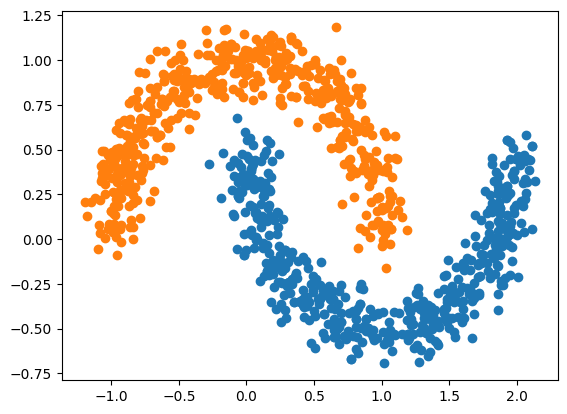

In [21]:
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])

In [22]:
vf

MLPUnconditionalVF(
  (_vf): ModuleDict(
    (time_features): FunctionalModule(
      (_identity): Identity()
    )
    (time_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=256, out_features=16, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=16, out_features=16, bias=True)
          (activation): Identity()
        )
      )
    )
    (state_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=2, out_features=32, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (activation): Identity()
        )
      )
    )
    (conditioning_layer): ConcatConditioning(
      (_identity): Identity()
    )
    (vf_decoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (

In [23]:
trainer.fit(train_dataloader=train_loader, num_iterations=10_000, valid_freq=10000)

  0%|                                                                                                                                       | 0/10000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.
/Users/mariia.minaeva/envs/sc_flow_tools/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
/var/folders/3c/c38sh9493qq83gp8s57blqq40000gn/T/ipykernel_76459/2127523856.py:168: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss.cpu())
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

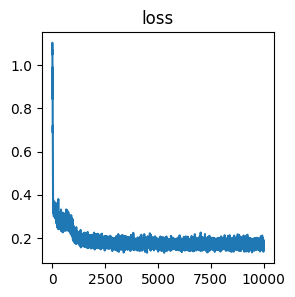

In [24]:
trainer.plot_training_logs()

In [25]:
preds = trainer._method.predict(data["src_cell_data"])

torch.Size([512, 2])


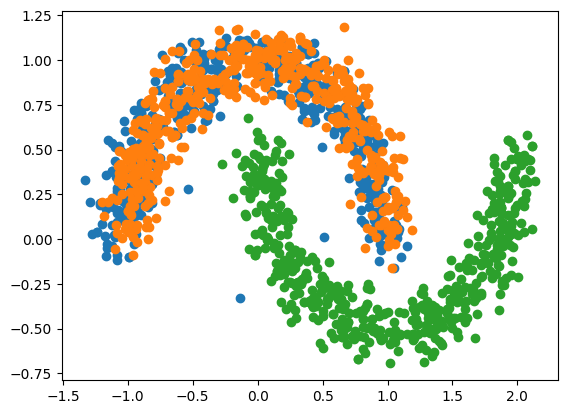

In [26]:
plt.scatter(preds[:, 0].detach().numpy(), preds[:, 1].detach().numpy())
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])